In [4]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

from svm_primal import PrimalSVM
from svm_dual import DualSVM
from kernels import linear_kernel, make_rbf_kernel, make_polynomial_kernel, make_laplacian_kernel
from utils import *

In [5]:
# Example usage for both models (uses test_linear function)
X, y = make_toy_data(n=11, random_state=42)

Training Primal SVM (linear)...
Iter 0, Obj=11.0000, GradNorm=19.8010, lr=0.0010, w=[0.016  0.0117], b=-0.00100000, grad_w=[-15.9783 -11.6522], grad_b=1.0000
Iter 1000, Obj=0.5018, GradNorm=1.4449, lr=0.0010, w=[0.7291 0.6855], b=0.03200000, grad_w=[ 0.7377 -0.7373], grad_b=-1.0000
Iter 2000, Obj=0.5008, GradNorm=1.4359, lr=0.0010, w=[0.7202 0.6942], b=0.02000000, grad_w=[ 0.7287 -0.7285], grad_b=-1.0000
Iter 3000, Obj=0.5016, GradNorm=1.4309, lr=0.0010, w=[0.7152 0.6991], b=0.01200000, grad_w=[ 0.7237 -0.7236], grad_b=-1.0000
Iter 4000, Obj=0.5004, GradNorm=1.4272, lr=0.0010, w=[0.7116 0.7027], b=0.00800000, grad_w=[ 0.7201 -0.72  ], grad_b=-1.0000
Iter 5000, Obj=0.5013, GradNorm=1.4194, lr=0.0010, w=[0.7105 0.7038], b=0.00400000, grad_w=[-0.7122  0.7123], grad_b=1.0000
Iter 6000, Obj=0.5007, GradNorm=1.4204, lr=0.0010, w=[0.7095 0.7048], b=0.00200000, grad_w=[-0.7132  0.7133], grad_b=1.0000
Iter 7000, Obj=0.5013, GradNorm=1.4236, lr=0.0010, w=[0.708  0.7062], b=0.00200000, grad_w=[ 0

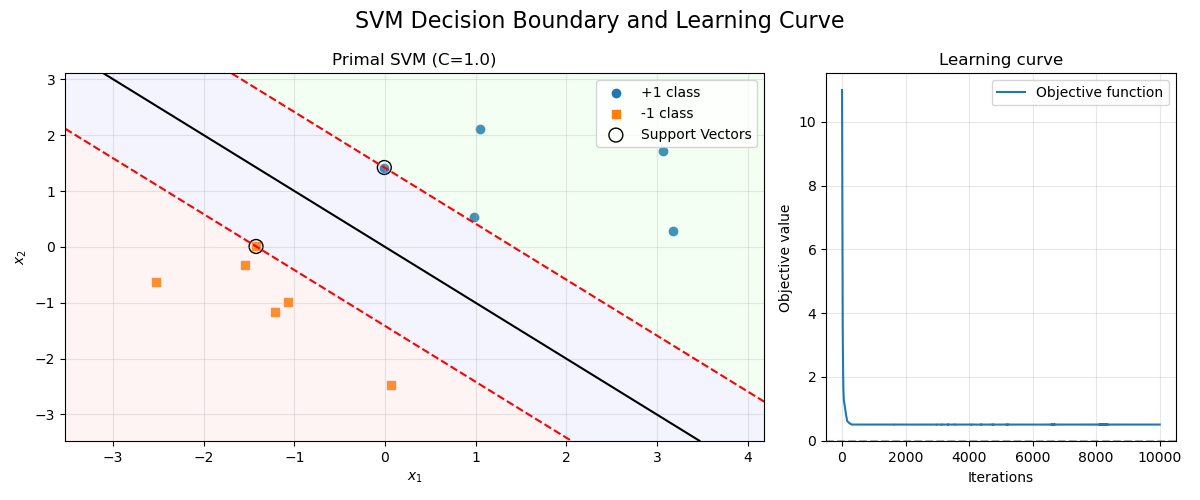

b: 6.938893903907228e-18, w: [0.70765636 0.70655998]
Margin: [3.38550479 2.45425048 1.07953976 0.99921818 2.23100829 1.31585499
 1.00078574 2.2281337  1.45336431 1.68534968 1.70709715]
Positive class support vectors: 1
Negative class support vectors: 1
b: 6.938893903907228e-18, w: [0.70765636 0.70655998]
Margin: [3.38550479 2.45425048 1.07953976 0.99921818 2.23100829 1.31585499
 1.00078574 2.2281337  1.45336431 1.68534968 1.70709715]
Positive class support vectors: 1
Negative class support vectors: 1
Number of support vectors: 2
b: 6.938893903907228e-18, w: [0.70765636 0.70655998]
Margin: [3.38550479 2.45425048 1.07953976 0.99921818 2.23100829 1.31585499
 1.00078574 2.2281337  1.45336431 1.68534968 1.70709715]
Positive class support vectors: 1
Negative class support vectors: 1
Support vectors: [3 6]
Number of X: 11


In [16]:
# Linear SVM - primal formulation
print("Training Primal SVM (linear)...")
primal_model = PrimalSVM(C=1.00, max_iter=10_000, tol=1e-12, lr=1e-3, bb_steps=True, verbose=True)
primal_model.fit(X, y)
primal_accuracy = primal_model.score(X, y)
print(f"Primal SVM accuracy: {primal_accuracy:.4f}")
plot_decision_boundary_2D(primal_model, X, y, title=f"Primal SVM (C={primal_model.C})")

primal_model.get_support_vectors()
print(f"Number of support vectors: {len(primal_model.get_support_vectors())}")
print(f"Support vectors: {primal_model.get_support_vectors()}")
primal_model.b
print(f"Number of X: {len(X)}")


Training Dual SVM (linear)...
Iter=0, Obj=-0.089401, Step=0.0277, ||alpha_diff||=3.303e-02
Dual SVM accuracy: 1.0000


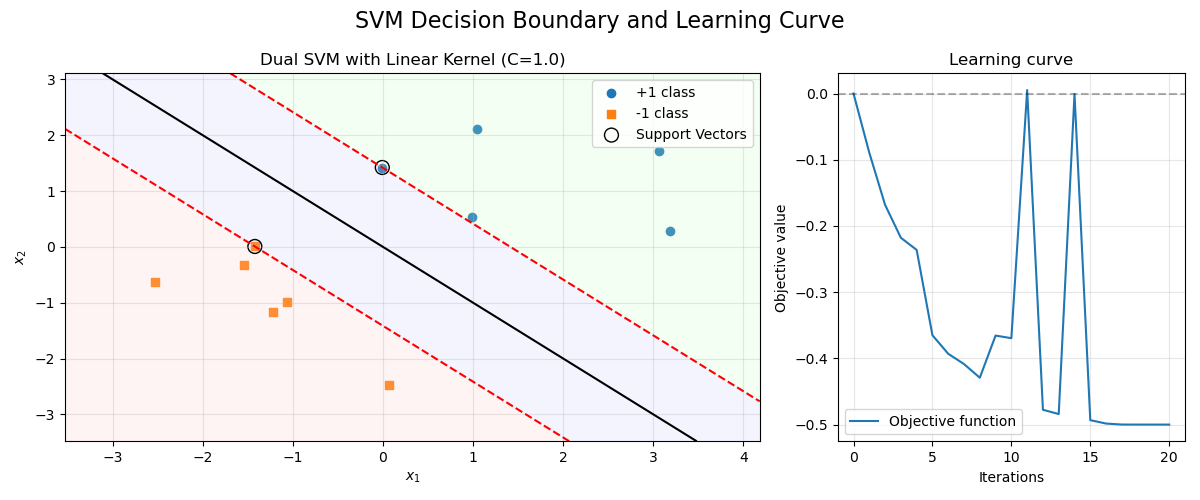

array([0.70710678, 0.70710678])

In [7]:

# Linear SVM - dual formulation
print("\nTraining Dual SVM (linear)...")
dual_model = DualSVM(C=1.0, max_iter=1000, tol=1e-6, kernel=linear_kernel, verbose=True)
dual_model.fit(X, y)
dual_accuracy = dual_model.score(X, y)
print(f"Dual SVM accuracy: {dual_accuracy:.4f}")
plot_decision_boundary_2D(dual_model, X, y, title=f"Dual SVM with Linear Kernel (C={dual_model.C})")
dual_model.recover_w()


Training Dual SVM (RBF kernel)...
Iter=0, Obj=-0.107835, Step=0.4344, ||alpha_diff||=3.303e-02
RBF Kernel SVM accuracy: 1.0000


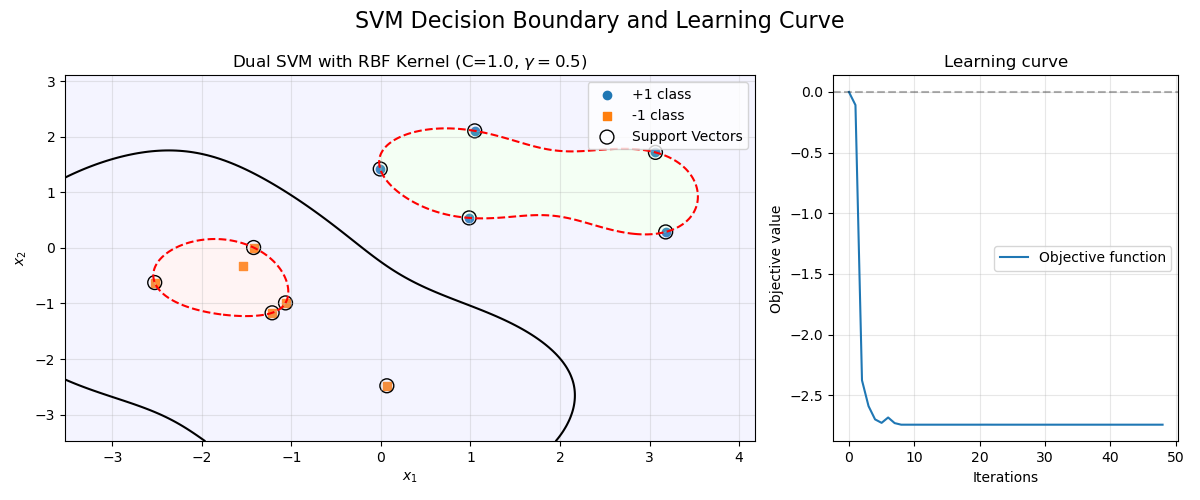

In [8]:

# Now try with an RBF kernel (non-linear)
print("\nTraining Dual SVM (RBF kernel)...")
rbf_kernel = make_rbf_kernel(gamma=0.5)
rbf_model = DualSVM(C=1.0, max_iter=1000, tol=1e-6, kernel=rbf_kernel, verbose=True)
rbf_model.fit(X, y)
rbf_accuracy = rbf_model.score(X, y)
print(f"RBF Kernel SVM accuracy: {rbf_accuracy:.4f}")
plot_decision_boundary_2D(rbf_model, X, y, title=f"Dual SVM with RBF Kernel (C={rbf_model.C}, $\\gamma=0.5$)")

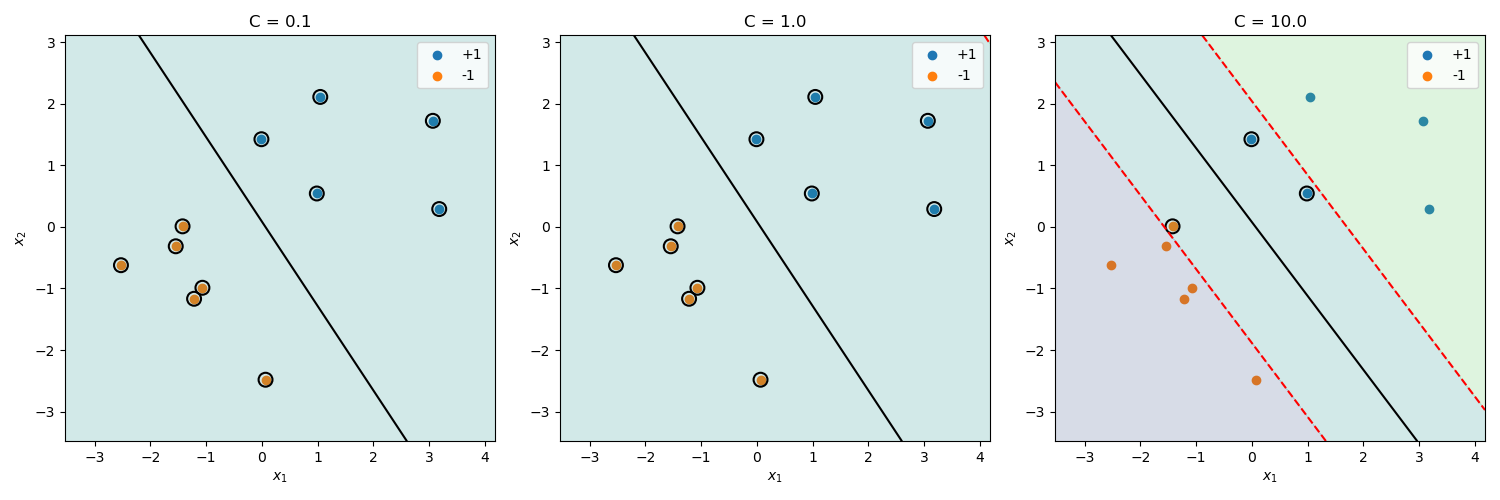

In [9]:
# Let's compare with different C values
C_values = [0.1, 1.0, 10.0]
plt.figure(figsize=(15, 5))

for i, C in enumerate(C_values):
    
    model = PrimalSVM(C=C, max_iter=1000, tol=1e-4)
    model.fit(X, y)
    plt.subplot(1, 3, i+1)
    plt.title(f"C = {C}")
    
    # Class scatter plot
    plt.scatter(X[y==+1,0], X[y==+1,1], label="+1")
    plt.scatter(X[y==-1,0], X[y==-1,1], label="-1")
    
    # Create mesh and predict
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    XX, YY = np.meshgrid(np.linspace(x_min, x_max, 100),
                       np.linspace(y_min, y_max, 100))
    Z = model.decision_function(np.c_[XX.ravel(), YY.ravel()])
    Z = Z.reshape(XX.shape)
    
    # Plot decision boundary and margins
    plt.contour(XX, YY, Z, levels=[-1, 0, 1], colors=['r', 'k', 'r'], 
               linestyles=['--', '-', '--'])
    plt.contourf(XX, YY, Z, levels=[-1e9, -1, 1, 1e9], alpha=0.2)
    
    # Show support vectors
    sv_indices = model.get_support_vectors()
    if len(sv_indices) > 0:
        plt.scatter(X[sv_indices, 0], X[sv_indices, 1], s=100, 
                   facecolors='none', edgecolors='k', linewidths=1.5)
    
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.legend()

plt.tight_layout()
plt.show()

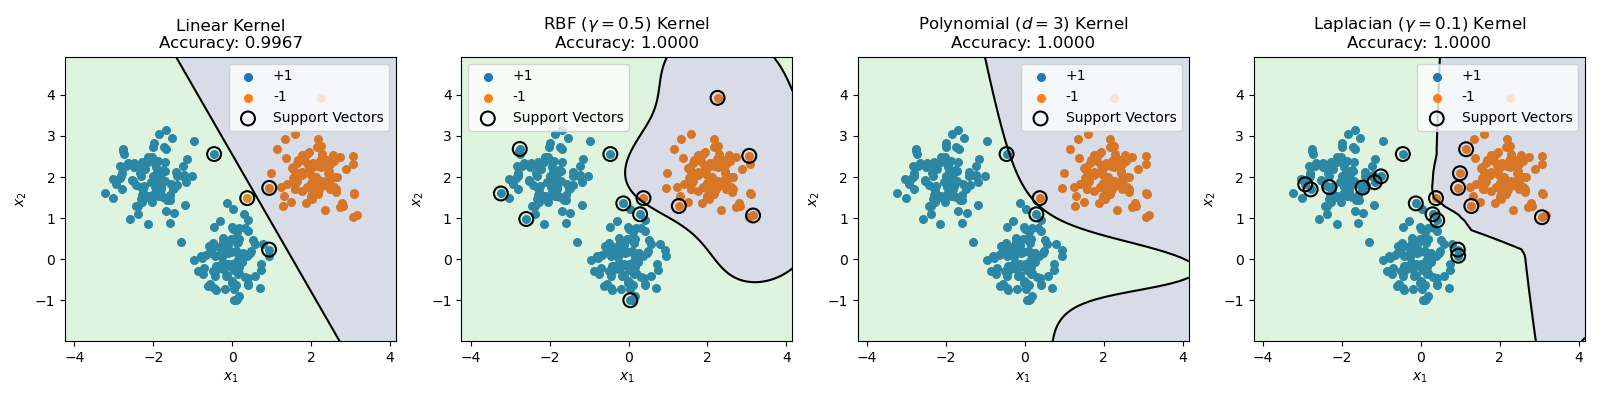

In [10]:
# Compare different kernels on a non-linear dataset
X_nl, y_nl = make_nonlinear_data(n=100, random_state=42)

# Create and compare models with different kernels
kernels = {
    "Linear": linear_kernel,
    "RBF ($\\gamma=0.5$)": make_rbf_kernel(gamma=0.5),
    "Polynomial ($d=3$)": make_polynomial_kernel(degree=3, coef0=0.1), 
    "Laplacian ($\\gamma=0.1$)": make_laplacian_kernel(gamma=0.1)
}

plt.figure(figsize=(16, 4))
for i, (name, kernel) in enumerate(kernels.items()):
    model = DualSVM(C=10.0, kernel=kernel, max_iter=1000)
    model.fit(X_nl, y_nl)
    acc = model.score(X_nl, y_nl)
    
    plt.subplot(1, 4, i+1)
    plt.title(f"{name} Kernel\nAccuracy: {acc:.4f}")
    
    # Plot data points
    plt.scatter(X_nl[y_nl==+1,0], X_nl[y_nl==+1,1], label="+1", s=30)
    plt.scatter(X_nl[y_nl==-1,0], X_nl[y_nl==-1,1], label="-1", s=30)
    
    # Create mesh and predict
    x_min, x_max = X_nl[:,0].min()-1, X_nl[:,0].max()+1
    y_min, y_max = X_nl[:,1].min()-1, X_nl[:,1].max()+1
    XX, YY = np.meshgrid(np.linspace(x_min, x_max, 100),
                       np.linspace(y_min, y_max, 100))
    Z = model.decision_function(np.c_[XX.ravel(), YY.ravel()])
    Z = Z.reshape(XX.shape)
    
    # Plot decision boundary
    plt.contour(XX, YY, Z, levels=[0], colors='k')
    plt.contourf(XX, YY, Z, levels=[-1e9, 0, 1e9], alpha=0.2)
    
    # Show support vectors
    sv_indices = model.get_support_vectors()
    if len(sv_indices) > 0:
        plt.scatter(X_nl[sv_indices, 0], X_nl[sv_indices, 1], s=100, 
                   facecolors='none', edgecolors='k', linewidths=1.5,
                   label="Support Vectors")
    
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.legend()

plt.tight_layout()
plt.show()


# Let's also test a real dataset from scikit-learn
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load and preprocess breast cancer dataset
cancer = load_breast_cancer()
X_cancer = cancer.data
y_cancer = 2 * cancer.target - 1  # Convert to {-1, 1}

# Scale features
scaler = StandardScaler()
X_cancer = scaler.fit_transform(X_cancer)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42
)

print(f"Dataset shape: {X_cancer.shape}")
print(f"Number of features: {X_cancer.shape[1]}")
print(f"Class distribution: {np.bincount(cancer.target)}")

# Try different kernels on this real dataset
kernels = {
    "Linear": linear_kernel,
    "RBF (gamma=0.01)": make_rbf_kernel(gamma=0.01),
    "Poly (d=2)": make_polynomial_kernel(degree=2, coef0=0.01),
    "Lapl (gamma=0.1)": make_laplacian_kernel(gamma=0.1)
}

# Create a results table
print("\nResults on Breast Cancer dataset:")
print("-" * 60)
print(f"{'Kernel':<15} | {'C':<5} | {'Train Accuracy':<15} | {'Test Accuracy':<15}")
print("-" * 60)

for name, kernel in kernels.items():
    for C in [0.1, 1.0, 10.0]:
        model = DualSVM(C=C, kernel=kernel, max_iter=1000, tol=1e-4)
        model.fit(X_train, y_train)
        
        train_acc = model.score(X_train, y_train)
        test_acc = model.score(X_test, y_test)
        
        print(f"{name:<15} | {C:<5.1f} | {train_acc:<15.4f} | {test_acc:<15.4f}")

print("-" * 60)

# Plot decision boundary for the best performing model using PCA for visualization
from sklearn.decomposition import PCA

# Train the best model on the full dataset
best_model = DualSVM(C=1.0, kernel=make_rbf_kernel(gamma=0.01), max_iter=1000)
best_model.fit(X_train, y_train)

# Use PCA to reduce the data to 2D for visualization
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

# Create a figure
plt.figure(figsize=(10, 8))
plt.title(f"PCA Visualization of Breast Cancer Dataset\nRBF Kernel ($\\gamma=0.01$), $C=1.0$, Test Accuracy: {best_model.score(X_test, y_test):.4f}")

# Plot the data points
plt.scatter(X_train_2d[y_train==+1, 0], X_train_2d[y_train==+1, 1], c='r', marker='o', alpha=0.6, label="Benign (Train)")
plt.scatter(X_train_2d[y_train==-1, 0], X_train_2d[y_train==-1, 1], c='b', marker='s', alpha=0.6, label="Malignant (Train)")
plt.scatter(X_test_2d[y_test==+1, 0], X_test_2d[y_test==+1, 1], c='darkred', marker='o', alpha=0.8, s=80, label="Benign (Test)")
plt.scatter(X_test_2d[y_test==-1, 0], X_test_2d[y_test==-1, 1], c='darkblue', marker='s', alpha=0.8, s=80, label="Malignant (Test)")

# Get support vectors in original space and project to 2D
sv_indices = best_model.get_support_vectors()
if len(sv_indices) > 0:
    plt.scatter(X_train_2d[sv_indices, 0], X_train_2d[sv_indices, 1], s=100, 
               facecolors='none', edgecolors='k', linewidths=1.5,
               label="Support Vectors")

# Create a mesh grid for the decision boundary
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                    np.linspace(y_min, y_max, 100))

# This is a workaround as we can't directly visualize the decision boundary in 2D PCA space
# We'll train a new SVM model on the 2D PCA data just for visualization
viz_model = DualSVM(C=1.0, kernel=make_rbf_kernel(gamma=0.1), max_iter=1000)
viz_model.fit(X_train_2d, y_train)
Z = viz_model.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.contour(xx, yy, Z, levels=[0], colors='k')
contourf = plt.contourf(xx, yy, Z, levels=[-1e9, 0, 1e9], alpha=0.2, colors=['blue', 'red'])

plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.5)

# Create a properly initialized ScalarMappable for the colorbar
norm = plt.Normalize(vmin=Z.min(), vmax=Z.max())
sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm, norm=norm)
sm.set_array([])  # You need to set an array for the ScalarMappable
plt.gcf().colorbar(sm, ax=plt.gca(), label='Decision Function Value')

plt.tight_layout()
plt.show()

# Print feature importance based on PCA
print("\nFeature importance (PCA components):")
feature_names = cancer.feature_names
for i, (eigen_val, eigen_vec) in enumerate(zip(pca.explained_variance_ratio_, pca.components_)):
    if i < 2:  # Only show first two components
        print(f"Principal Component {i+1} (Explains {eigen_val*100:.2f}% of variance)")
        # Get the top 5 features contributing to this component
        indices = np.argsort(np.abs(eigen_vec))[-5:][::-1]
        for idx in indices:
            print(f"  {feature_names[idx]}: {eigen_vec[idx]:.4f}")